# 09a — Macro Feature Ablation Test

**Objective**: Validate the notebook 03 multicollinearity decisions by testing whether dropping 11 redundant macro features (while retaining one representative per group) causes meaningful performance loss in XGBoost.

**Context**: X_train carries all 27 features (Option B). Notebook 03 identified three collinear groups and selected one representative each:

| Group | Drop (11 features) | Keep (representative) |
|---|---|---|
| Interest rates | `1Y_TBills`, `2Y_Bond_Yield`, `5Y_Bond_Yield`, `10Y_Bond_Yield`, `15Y_Bond_Yield`, `20Y_Bond_Yield` | `SORA_3M_Compounded` |
| Construction costs | `Cement_Bulk_Per_Tonne`, `Steel_Rebar_Per_Tonne`, `Granite_20mm_Per_Tonne`, `Concreting_Sand_Per_Tonne` | `Ready_Mixed_Concrete_Per_m3` |
| Economic | `Unemployment_Rate` | `GDP_YoY_Growth_Rate`, `CPI_All_Items` |

**Approach**: Retrain XGBoost with the same best hyperparameters on 16 features (27 - 11 dropped). Compare CV RMSE and test RMSE against the full 27-feature model.

**Decision rule**: If RMSE increase < $2 $/psf → drop confirmed. Notebook 03 decisions are validated. Otherwise → retain redundant features.

---

## 1. Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

X_train = pd.read_csv("../nb_models/X_train.csv")
X_test  = pd.read_csv("../nb_models/X_test.csv")
y_train = pd.read_csv("../nb_models/y_train.csv")
y_test  = pd.read_csv("../nb_models/y_test.csv")

y_train_raw = y_train["Unit Price ($ psf)"]
y_test_raw  = y_test["Unit Price ($ psf)"]

# Best XGBoost hyperparameters from notebook 08
xgb_full = joblib.load("../nb_models/xgboost.pkl")
best_params = {
    "n_estimators":     xgb_full.n_estimators,
    "max_depth":        xgb_full.max_depth,
    "learning_rate":    xgb_full.learning_rate,
    "subsample":        xgb_full.subsample,
    "colsample_bytree": xgb_full.colsample_bytree,
    "random_state":     42,
    "n_jobs":           -1,
    "verbosity":        0,
}

# 11 redundant features to drop — representatives retained per group
# Interest rates: keep SORA_3M_Compounded
# Construction:   keep Ready_Mixed_Concrete_Per_m3
# Economic:       keep GDP_YoY_Growth_Rate, CPI_All_Items
MACRO_COLS_TO_DROP = [
    # Interest rates / bond yields
    "1Y_TBills", "2Y_Bond_Yield", "5Y_Bond_Yield",
    "10Y_Bond_Yield", "15Y_Bond_Yield", "20Y_Bond_Yield",
    # Construction costs
    "Cement_Bulk_Per_Tonne", "Steel_Rebar_Per_Tonne",
    "Granite_20mm_Per_Tonne", "Concreting_Sand_Per_Tonne",
    # Economic
    "Unemployment_Rate",
]

print(f"Full feature set:    {X_train.shape[1]} features")
print(f"Reduced feature set: {X_train.shape[1] - len(MACRO_COLS_TO_DROP)} features ({len(MACRO_COLS_TO_DROP)} redundant macro removed)")
print(f"\nBest XGBoost params: {best_params}")

Full feature set:    27 features
Reduced feature set: 16 features (11 redundant macro removed)

Best XGBoost params: {'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}


## 2. Full Model — Baseline (from Notebook 08)

In [2]:
# CV RMSE on full feature set
cv_full = cross_val_score(
    XGBRegressor(**best_params), X_train, y_train_raw,
    cv=5, scoring="neg_root_mean_squared_error"
)
cv_rmse_full = -cv_full.mean()

# Test RMSE on full feature set
y_pred_full = xgb_full.predict(X_test)
rmse_full = np.sqrt(mean_squared_error(y_test_raw, y_pred_full))
mae_full  = np.mean(np.abs(y_test_raw.values - y_pred_full))
r2_full   = r2_score(y_test_raw, y_pred_full)

print(f"Full model ({X_train.shape[1]} features):")
print(f"  CV RMSE:   ${cv_rmse_full:.2f} $/psf")
print(f"  Test RMSE: ${rmse_full:.2f} $/psf")
print(f"  Test MAE:  ${mae_full:.2f} $/psf")
print(f"  Test R²:   {r2_full:.4f}")

Full model (27 features):
  CV RMSE:   $50.80 $/psf
  Test RMSE: $48.80 $/psf
  Test MAE:  $32.48 $/psf
  Test R²:   0.9267


## 3. Reduced Model — Macro Features Removed

In [3]:
X_train_reduced = X_train.drop(columns=MACRO_COLS_TO_DROP)
X_test_reduced  = X_test.drop(columns=MACRO_COLS_TO_DROP)

# CV RMSE on reduced feature set
cv_reduced = cross_val_score(
    XGBRegressor(**best_params), X_train_reduced, y_train_raw,
    cv=5, scoring="neg_root_mean_squared_error"
)
cv_rmse_reduced = -cv_reduced.mean()

# Train and evaluate reduced model
xgb_reduced = XGBRegressor(**best_params)
xgb_reduced.fit(X_train_reduced, y_train_raw)

y_pred_reduced = xgb_reduced.predict(X_test_reduced)
rmse_reduced = np.sqrt(mean_squared_error(y_test_raw, y_pred_reduced))
mae_reduced  = np.mean(np.abs(y_test_raw.values - y_pred_reduced))
r2_reduced   = r2_score(y_test_raw, y_pred_reduced)

print(f"Reduced model ({X_train_reduced.shape[1]} features, redundant macro removed):")
print(f"  CV RMSE:   ${cv_rmse_reduced:.2f} $/psf")
print(f"  Test RMSE: ${rmse_reduced:.2f} $/psf")
print(f"  Test MAE:  ${mae_reduced:.2f} $/psf")
print(f"  Test R²:   {r2_reduced:.4f}")

Reduced model (16 features, redundant macro removed):
  CV RMSE:   $50.01 $/psf
  Test RMSE: $47.44 $/psf
  Test MAE:  $31.32 $/psf
  Test R²:   0.9307


## 4. Ablation Results & Decision

In [4]:
rmse_delta    = rmse_reduced - rmse_full
cv_rmse_delta = cv_rmse_reduced - cv_rmse_full
r2_delta      = r2_reduced - r2_full

comparison = pd.DataFrame({
    "Model":        [f"Full ({X_train.shape[1]} features)", f"Reduced ({X_train_reduced.shape[1]} features)", "Delta (Reduced - Full)"],
    "CV RMSE":      [f"${cv_rmse_full:.2f} $/psf", f"${cv_rmse_reduced:.2f} $/psf", f"${cv_rmse_delta:+.2f} $/psf"],
    "Test RMSE":    [f"${rmse_full:.2f} $/psf", f"${rmse_reduced:.2f} $/psf", f"${rmse_delta:+.2f} $/psf"],
    "Test MAE":     [f"${mae_full:.2f} $/psf", f"${mae_reduced:.2f} $/psf", f"${mae_reduced-mae_full:+.2f} $/psf"],
    "Test R²":      [f"{r2_full:.4f}", f"{r2_reduced:.4f}", f"{r2_delta:+.4f}"],
})

print(comparison.to_string(index=False))
print()
print("=" * 55)
print("DECISION")
print("=" * 55)
THRESHOLD = 2.0
if rmse_delta <= THRESHOLD:
    print(f"RMSE increase: ${rmse_delta:.2f} $/psf — below ${THRESHOLD:.0f} threshold")
    print("=> DROP macro features. Performance loss is negligible.")
    print("   Simpler model, fewer external data dependencies.")
else:
    print(f"RMSE increase: ${rmse_delta:.2f} $/psf — above ${THRESHOLD:.0f} threshold")
    print("=> RETAIN macro features. Performance loss is meaningful.")

                 Model      CV RMSE    Test RMSE     Test MAE Test R²
    Full (27 features) $50.80 $/psf $48.80 $/psf $32.48 $/psf  0.9267
 Reduced (16 features) $50.01 $/psf $47.44 $/psf $31.32 $/psf  0.9307
Delta (Reduced - Full) $-0.80 $/psf $-1.35 $/psf $-1.16 $/psf +0.0040

DECISION
RMSE increase: $-1.35 $/psf — below $2 threshold
=> DROP macro features. Performance loss is negligible.
   Simpler model, fewer external data dependencies.


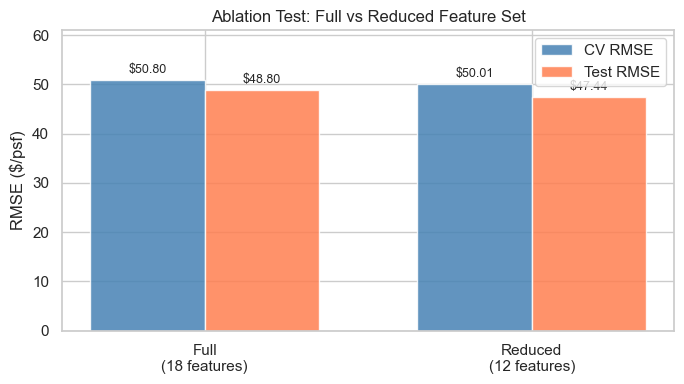

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))

models   = ["Full\n(18 features)", "Reduced\n(12 features)"]
cv_rmses = [cv_rmse_full, cv_rmse_reduced]
te_rmses = [rmse_full, rmse_reduced]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, cv_rmses, width, label="CV RMSE", color="steelblue", alpha=0.85)
bars2 = ax.bar(x + width/2, te_rmses, width, label="Test RMSE", color="coral", alpha=0.85)

ax.bar_label(bars1, fmt="$%.2f", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="$%.2f", padding=3, fontsize=9)

ax.set_ylabel("RMSE ($/psf)")
ax.set_title("Ablation Test: Full vs Reduced Feature Set")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, max(cv_rmses + te_rmses) * 1.2)

plt.tight_layout()
plt.show()

## 5. Retune XGBoost on Reduced Feature Set

The reduced model above reused hyperparameters tuned on 27 features. With 11 noisy features removed, the optimal settings may differ — less regularisation may be needed on cleaner data.

Same grid as notebook 08 for a fair comparison.

In [6]:
param_grid = {
    "n_estimators":     [100, 200],
    "max_depth":        [3, 5, 7],
    "learning_rate":    [0.05, 0.1, 0.3],
    "subsample":        [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

grid_search_reduced = GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
)
grid_search_reduced.fit(X_train_reduced, y_train_raw)

print(f"Best params (reduced feature set):")
for k, v in grid_search_reduced.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV RMSE: ${-grid_search_reduced.best_score_:.2f} $/psf")

Fitting 5 folds for each of 72 candidates, totalling 360 fits


Best params (reduced feature set):
  colsample_bytree: 1.0
  learning_rate: 0.05
  max_depth: 7
  n_estimators: 200
  subsample: 0.8

Best CV RMSE: $49.83 $/psf


In [7]:
xgb_retuned = grid_search_reduced.best_estimator_

y_pred_retuned = xgb_retuned.predict(X_test_reduced)
rmse_retuned = np.sqrt(mean_squared_error(y_test_raw, y_pred_retuned))
mae_retuned  = np.mean(np.abs(y_test_raw.values - y_pred_retuned))
r2_retuned   = r2_score(y_test_raw, y_pred_retuned)
cv_rmse_retuned = -grid_search_reduced.best_score_

print("Three-way comparison:")
print()
comparison3 = pd.DataFrame({
    "Model": [
        f"Full ({X_train.shape[1]} features, original params)",
        f"Reduced ({X_train_reduced.shape[1]} features, original params)",
        f"Reduced ({X_train_reduced.shape[1]} features, retuned)",
    ],
    "CV RMSE":   [f"${cv_rmse_full:.2f}",    f"${cv_rmse_reduced:.2f}",  f"${cv_rmse_retuned:.2f}"],
    "Test RMSE": [f"${rmse_full:.2f}",       f"${rmse_reduced:.2f}",     f"${rmse_retuned:.2f}"],
    "Test MAE":  [f"${mae_full:.2f}",        f"${mae_reduced:.2f}",      f"${mae_retuned:.2f}"],
    "Test R2":   [f"{r2_full:.4f}",          f"{r2_reduced:.4f}",        f"{r2_retuned:.4f}"],
})
print(comparison3.to_string(index=False))
print()

# Champion decision
best_rmse = min(rmse_full, rmse_reduced, rmse_retuned)
if best_rmse == rmse_retuned:
    champion = f"Reduced + retuned ({X_train_reduced.shape[1]} features)"
elif best_rmse == rmse_reduced:
    champion = f"Reduced original params ({X_train_reduced.shape[1]} features)"
else:
    champion = f"Full model ({X_train.shape[1]} features)"

print("=" * 55)
print("CHAMPION: " + champion)
print(f"Test RMSE: ${best_rmse:.2f} $/psf")
print(f"Test R2:   {max(r2_full, r2_reduced, r2_retuned):.4f}")

Three-way comparison:

                                 Model CV RMSE Test RMSE Test MAE Test R2
   Full (27 features, original params)  $50.80    $48.80   $32.48  0.9267
Reduced (16 features, original params)  $50.01    $47.44   $31.32  0.9307
        Reduced (16 features, retuned)  $49.83    $47.26   $30.88  0.9312

CHAMPION: Reduced + retuned (16 features)
Test RMSE: $47.26 $/psf
Test R2:   0.9312


## 6. Experiment — Drop All Macro Features

The archived notebooks dropped **all** macro features (including representatives) and achieved a lower RMSE than keeping representatives. This experiment replicates that approach on the revamped data pipeline to test whether the result holds.

All 15 macro/economic/construction features are removed, leaving only property-specific features:
`Log_Area`, `Remaining_Lease_Years`, `Lease_Remaining_Ratio`, `dist_to_mrt_m`, `Planning_Area_Encoded`, and the 7 one-hot encoded categoricals.

In [8]:
# All macro/economic/construction features — including representatives
ALL_MACRO_COLS = [
    # Economic
    "GDP_YoY_Growth_Rate", "CPI_All_Items", "Unemployment_Rate",
    # Interest rates / bond yields
    "1Y_TBills", "2Y_Bond_Yield", "5Y_Bond_Yield",
    "10Y_Bond_Yield", "15Y_Bond_Yield", "20Y_Bond_Yield", "SORA_3M_Compounded",
    # Construction costs
    "Cement_Bulk_Per_Tonne", "Steel_Rebar_Per_Tonne",
    "Granite_20mm_Per_Tonne", "Concreting_Sand_Per_Tonne",
    "Ready_Mixed_Concrete_Per_m3",
]

X_train_no_macro = X_train.drop(columns=ALL_MACRO_COLS)
X_test_no_macro  = X_test.drop(columns=ALL_MACRO_COLS)

print(f"No-macro feature set: {X_train_no_macro.shape[1]} features")
print(f"Dropped {len(ALL_MACRO_COLS)} features, retained: {list(X_train_no_macro.columns)}")

No-macro feature set: 12 features
Dropped 15 features, retained: ['Log_Area', 'Remaining_Lease_Years', 'Lease_Remaining_Ratio', 'dist_to_mrt_m', 'Planning_Area_Encoded', 'Region_East Region', 'Region_North Region', 'Region_North-East Region', 'Region_West Region', 'Floor Level_Non-First Floor', 'Floor Level_Unknown', 'Type of Sale_Resale']


### 6a. Retune XGBoost on No-Macro Feature Set

In [9]:
param_grid = {
    "n_estimators":     [100, 200],
    "max_depth":        [3, 5, 7],
    "learning_rate":    [0.05, 0.1, 0.3],
    "subsample":        [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

grid_search_no_macro = GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
)
grid_search_no_macro.fit(X_train_no_macro, y_train_raw)

print(f"Best params (no-macro feature set):")
for k, v in grid_search_no_macro.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV RMSE: ${-grid_search_no_macro.best_score_:.2f} $/psf")

Fitting 5 folds for each of 72 candidates, totalling 360 fits


Best params (no-macro feature set):
  colsample_bytree: 1.0
  learning_rate: 0.05
  max_depth: 7
  n_estimators: 200
  subsample: 0.8

Best CV RMSE: $47.31 $/psf


In [10]:
xgb_no_macro = grid_search_no_macro.best_estimator_

y_pred_no_macro = xgb_no_macro.predict(X_test_no_macro)
rmse_no_macro = np.sqrt(mean_squared_error(y_test_raw, y_pred_no_macro))
mae_no_macro  = np.mean(np.abs(y_test_raw.values - y_pred_no_macro))
r2_no_macro   = r2_score(y_test_raw, y_pred_no_macro)
cv_rmse_no_macro = -grid_search_no_macro.best_score_

print("Four-way comparison:")
print()
comparison4 = pd.DataFrame({
    "Model": [
        f"Full ({X_train.shape[1]} features)",
        f"Reduced ({X_train_reduced.shape[1]} features, original params)",
        f"Reduced ({X_train_reduced.shape[1]} features, retuned)",
        f"No-macro ({X_train_no_macro.shape[1]} features, retuned)",
    ],
    "CV RMSE":   [f"${cv_rmse_full:.2f}",     f"${cv_rmse_reduced:.2f}",  f"${cv_rmse_retuned:.2f}",  f"${cv_rmse_no_macro:.2f}"],
    "Test RMSE": [f"${rmse_full:.2f}",        f"${rmse_reduced:.2f}",     f"${rmse_retuned:.2f}",     f"${rmse_no_macro:.2f}"],
    "Test MAE":  [f"${mae_full:.2f}",         f"${mae_reduced:.2f}",      f"${mae_retuned:.2f}",      f"${mae_no_macro:.2f}"],
    "Test R2":   [f"{r2_full:.4f}",           f"{r2_reduced:.4f}",        f"{r2_retuned:.4f}",        f"{r2_no_macro:.4f}"],
})
print(comparison4.to_string(index=False))
print()

# Champion decision across all 4 models
all_rmses = {
    f"Full ({X_train.shape[1]} features)": rmse_full,
    f"Reduced ({X_train_reduced.shape[1]} features, retuned)": rmse_retuned,
    f"No-macro ({X_train_no_macro.shape[1]} features, retuned)": rmse_no_macro,
}
champion = min(all_rmses, key=all_rmses.get)
print("=" * 60)
print("CHAMPION: " + champion)
print(f"Test RMSE: ${all_rmses[champion]:.2f} $/psf")

Four-way comparison:

                                 Model CV RMSE Test RMSE Test MAE Test R2
                    Full (27 features)  $50.80    $48.80   $32.48  0.9267
Reduced (16 features, original params)  $50.01    $47.44   $31.32  0.9307
        Reduced (16 features, retuned)  $49.83    $47.26   $30.88  0.9312
       No-macro (12 features, retuned)  $47.31    $47.53   $30.55  0.9304

CHAMPION: Reduced (16 features, retuned)
Test RMSE: $47.26 $/psf


In [11]:
# Save both reduced and no-macro models for reference
joblib.dump(xgb_retuned,  "../nb_models/xgboost_reduced.pkl")
joblib.dump(xgb_no_macro, "../nb_models/xgboost_no_macro.pkl")

print("Saved:")
print("  nb_models/xgboost_reduced.pkl  — 16 features (representatives retained), retuned")
print("  nb_models/xgboost_no_macro.pkl — 12 features (all macro dropped), retuned")
print()
print("Four-way RMSE summary:")
print(f"  Full (27 features):              ${rmse_full:.2f} $/psf")
print(f"  Reduced (16 features, retuned):  ${rmse_retuned:.2f} $/psf")
print(f"  No-macro (12 features, retuned): ${rmse_no_macro:.2f} $/psf")
print()
champion_rmse = min(rmse_full, rmse_retuned, rmse_no_macro)
if champion_rmse == rmse_no_macro:
    print("=> CHAMPION: No-macro model. Macro features add noise — drop all.")
elif champion_rmse == rmse_retuned:
    print("=> CHAMPION: Reduced model. Representatives contribute marginal signal — keep them.")
else:
    print("=> CHAMPION: Full model. All features contribute — keep everything.")

Saved:
  nb_models/xgboost_reduced.pkl  — 16 features (representatives retained), retuned
  nb_models/xgboost_no_macro.pkl — 12 features (all macro dropped), retuned

Four-way RMSE summary:
  Full (27 features):              $48.80 $/psf
  Reduced (16 features, retuned):  $47.26 $/psf
  No-macro (12 features, retuned): $47.53 $/psf

=> CHAMPION: Reduced model. Representatives contribute marginal signal — keep them.
